In [1]:
from pyscf import gto, scf, cc

a = 2 # bond length in a cluster
d = 100 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 2 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'N'
basis = 'sto6g'
# for nc in nc_list:
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"

mol = gto.M(atom=atoms, basis="sto6g", unit='B', spin=0, verbose=4)
mol.build()

mf = scf.RHF(mol)
mf.kernel()

mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)

nfrozen = 0
mycc = cc.CCSD(mf,frozen=nfrozen)
mycc.kernel()[0]

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-14-generic', version='#14~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Jan 15 15:52:10 UTC 2', machine='x86_64')  Threads 16
Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
numpy 2.3.1  scipy 1.16.2  h5py 3.14.0
Date: Wed Mar  4 16:24:14 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 4
[INPUT] num. electrons = 28
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 N      0.000000000000   0.000000000000   0.000000000000 AA   

np.float64(-0.28767088678754843)

In [3]:
# example for PT2

options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 50,
            'n_walkers': 300,
            'seed': 2,
            'walker_type': 'rhf',
            'trial': 'stoccsd2',
            'nslater': 1,
            'dt':0.005,
            'use_gpu': False,
            }

from ad_afqmc.prop_unrestricted.mixed_wave import prep
import jax
jax.config.update("jax_enable_x64", True)
prep.prep_afqmc(mycc,chol_cut=1e-5)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (14, 14)
# Number of basis functions: 20
# Number of Cholesky vectors: 84
#


In [4]:
import time
import numpy as np
from jax import random
from jax import numpy as jnp
from functools import partial 

ham_data, ham, prop, trial, wave_data, sampler, options = (prep._prep_afqmc())

init_time = time.time()

### initialize propagation
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(options["seed"])

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0

e_init= jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data)[0])
prop_data["e_estimate"] = e_init
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

print(e_init)
print(e_init-mf.e_tot)

# Throw 42 vectors in T2 deomposition
# cutoff = 1.00e-08 | error = 6.39e-16
# number of T2 decomposition vectors 42
# nelec: (14, 14)
# norb: 20
# nchol: 84
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 50
# n_walkers: 300
# seed: 2
# walker_type: rhf
# trial: stoccsd2
# nslater: 1
# dt: 0.005
# use_gpu: False
# n_exp_terms: 6
# n_batch: 1
# max_error: 0.001
-217.04692627516442
3.0668191982385906e-05


In [5]:
from jax import jit, lax

@partial(jit, static_argnums=(0,3,4))
def _block(
    self,
    prop_data: dict,
    ham_data: dict,
    prop,
    trial,
    wave_data: dict
    ):
    """Block scan function. Propagation and energy calculation."""

    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            self.n_prop_steps,
            prop.n_walkers,
            self.n_chol,
        ),
    )
    _step_scan_wrapper = lambda x, y: self._step_scan(
        x, y, ham_data, prop, trial, wave_data
    )
    prop_data, _ = lax.scan(_step_scan_wrapper, prop_data, fields)
    prop_data["n_killed_walkers"] += prop_data["weights"].size - jnp.count_nonzero(
        prop_data["weights"]
    )

    # fields_x for T2 decomposition
    prop_data["key"], subkey = random.split(prop_data["key"])
    fields_x = random.normal(
        subkey,
        shape=(
            prop.n_walkers,
            trial.nslater,
            wave_data['tau'].shape[0],
        ),
    )

    xtaus = jnp.einsum("wsg,gia->wsia", fields_x, wave_data['tau'])

    prop_data = prop.orthonormalize_walkers(prop_data)
    overlap_hf = trial.calc_overlap(prop_data["walkers"], wave_data)
    prop_data["overlaps"] = overlap_hf
    overlap_ci, energy_ci = trial.calc_energy_cid(prop_data["walkers"], ham_data, wave_data)
    numerator_cr, denominator_cr = trial.calc_correction(prop_data["walkers"], xtaus, ham_data, wave_data)

    num_ci = overlap_ci * energy_ci / overlap_hf
    den_ci = overlap_ci / overlap_hf
    num_cr = numerator_cr / overlap_hf
    den_cr = denominator_cr / overlap_hf

    whf = prop_data["weights"]

    blk_whf = jnp.sum(whf)

    blk_num_ci = jnp.sum(whf * num_ci) / blk_whf
    blk_den_ci = jnp.sum(whf * den_ci) / blk_whf
    blk_num_cr = jnp.sum(whf * num_cr) / blk_whf
    blk_den_cr = jnp.sum(whf * den_cr) / blk_whf

    prop_data = prop.stochastic_reconfiguration_local(prop_data)
    prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)

    return prop_data, (blk_whf, blk_num_ci, blk_den_ci, blk_num_cr, blk_den_cr)


In [6]:
neql = 40
block_time = prop.dt * sampler.n_prop_steps

for n in range(neql):
    prop_data, (whf, num_ci, den_ci, num_cr, den_cr) \
        = _block(sampler, prop_data, ham_data, prop, trial, wave_data)

    eci = num_ci / den_ci
    ecc = (num_ci + num_cr) / (den_ci + den_cr)

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * eci.real
    key = prop_data["key"]

    print(f" {(n+1)*block_time:.2f}  {eci.real:.6f}  {num_cr.real:.6f}  {den_cr.real:.6f}  {ecc.real:.6f}  {time.time() - init_time:.2f} ")

 0.25  -217.327623  -3.101551  0.014320  -217.317790  8.12 
 0.50  -217.329581  -1.071905  0.004951  -217.325784  11.37 
 0.75  -217.330102  -1.518417  0.006957  -217.335865  11.63 
 1.00  -217.335764  0.647299  -0.003124  -217.363944  11.89 
 1.25  -217.338081  -3.169454  0.014560  -217.342197  12.16 
 1.50  -217.345860  -0.390590  0.001768  -217.351374  12.42 
 1.75  -217.336956  0.069615  -0.000384  -217.348907  12.68 
 2.00  -217.340549  2.767611  -0.012920  -217.376219  12.95 
 2.25  -217.341568  -8.620085  0.039731  -217.328735  13.21 
 2.50  -217.339994  6.566502  -0.030583  -217.412006  13.47 
 2.75  -217.497290  -54.663997  0.253456  -217.180276  13.74 
 3.00  -217.373386  -11.480766  0.053234  -217.299941  14.00 
 3.25  -217.346321  1.089856  -0.005417  -217.421313  14.26 
 3.50  -217.351433  -7.767924  0.035849  -217.331320  14.53 
 3.75  -217.336368  1.672674  -0.007926  -217.379703  14.79 
 4.00  -217.339683  -3.238279  0.014884  -217.342546  15.05 
 4.25  -217.340134  -1.

In [7]:
nsample = 400
whf_sp = np.zeros(nsample,dtype="float64")
numci_sp = np.zeros(nsample,dtype="complex128")
denci_sp = np.zeros(nsample,dtype="complex128")#float64")
numcr_sp = np.zeros(nsample,dtype="complex128")
dencr_sp = np.zeros(nsample,dtype="complex128")

for n in range(nsample):
    prop_data, (whf, numci, denci, numcr, dencr) \
        = _block(sampler, prop_data, ham_data, prop, trial, wave_data)
    key = prop_data["key"]
    
    prop_data = prop.orthonormalize_walkers(prop_data)
    prop_data = prop.stochastic_reconfiguration_local(prop_data)

    whf_sp[n] = whf
    

    numci_sp[n] = numci
    denci_sp[n] = denci
    numcr_sp[n] = numcr
    dencr_sp[n] = dencr

    whf = np.sum(whf_sp[:n+1])
    whf_numci = np.sum(whf_sp[:n+1] * numci_sp[:n+1])
    whf_denci = np.sum(whf_sp[:n+1] * denci_sp[:n+1])
    whf_numcr = np.sum(whf_sp[:n+1] * numcr_sp[:n+1])
    whf_dencr = np.sum(whf_sp[:n+1] * dencr_sp[:n+1])

    numci = whf_numci / whf
    denci = whf_denci / whf
    eci = numci / denci

    numcr = whf_numcr / whf
    dencr = whf_dencr / whf
    ecc = (numci + numcr) / (denci + dencr)

    if n > 1:
        # partial_eci/partial_num, partial_eci/partial_don
        deci = [1/denci, -numci/denci**2]
        covci = np.cov([numci_sp[:n+1], denci_sp[:n+1]])
        eci_err = np.sqrt(deci @ covci @ deci) / np.sqrt((n))
        
        # partial_ecc...
        decc = [1/(denci+dencr), 
                1/(denci+dencr), 
                -(numci+numcr)/(denci+dencr)**2, 
                -(numci+numcr)/(denci+dencr)**2,
                ]
        covcc = np.cov([numci_sp[:n+1], numcr_sp[:n+1], denci_sp[:n+1], dencr_sp[:n+1]])
        ecc_err = np.sqrt(decc @ covcc @ decc) / np.sqrt((n))

        print(f" {n+1}  {eci.real:.6f}  {eci_err.real:.6f}  {ecc.real:.6f}  {ecc_err.real:.6f}")

 3  -217.332602  0.002112  -217.367131  0.019148
 4  -217.334081  0.002214  -217.367595  0.014556
 5  -217.334612  0.001786  -217.368084  0.010974
 6  -217.335918  0.002019  -217.370429  0.009811
 7  -217.336045  0.001700  -217.367022  0.008984
 8  -217.335446  0.001599  -217.368231  0.008040
 9  -217.335206  0.001439  -217.364380  0.008127
 10  -217.334712  0.001398  -217.360201  0.008426
 11  -217.335117  0.001328  -217.361326  0.007727
 12  -217.335561  0.001292  -217.356969  0.008620
 13  -217.335701  0.001200  -217.353855  0.008522
 14  -217.335539  0.001121  -217.353678  0.007871
 15  -217.335860  0.001113  -217.351367  0.007667
 16  -217.336164  0.001101  -217.353619  0.008131
 17  -217.335982  0.001054  -217.353426  0.007702
 18  -217.335927  0.001010  -217.351776  0.007453
 19  -217.336252  0.001024  -217.354007  0.007447
 20  -217.336327  0.001064  -217.353799  0.007093
 21  -217.336229  0.001016  -217.353287  0.006862
 22  -217.336150  0.000975  -217.352424  0.006598
 23  -2

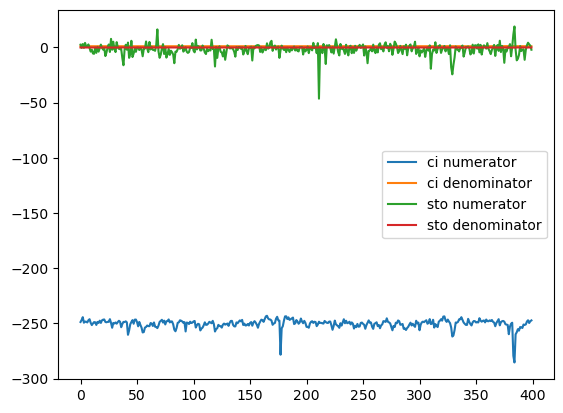

In [19]:
from matplotlib import pyplot as plt

plt.plot(numci_sp.real,label='ci numerator')
plt.plot(denci_sp.real,label='ci denominator')
plt.plot(numcr_sp.real,label='sto numerator')
plt.plot(dencr_sp.real,label='sto denominator')
plt.legend()
plt.show()

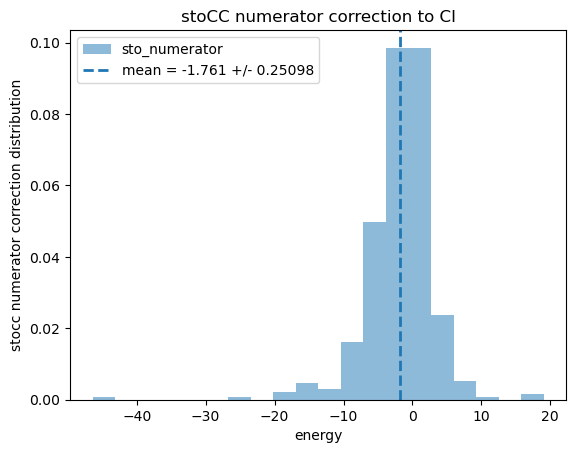

In [20]:
from matplotlib import pyplot as plt
plt.figure()
plt.hist(numcr_sp.real, bins=20, alpha=0.5, density=True, color='C0', label='sto_numerator')
mean = np.mean(numcr_sp.real)
sigma = np.std(numcr_sp.real)/np.sqrt(len(numcr_sp))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc numerator correction distribution")
plt.title("stoCC numerator correction to CI")
plt.legend()
plt.show()

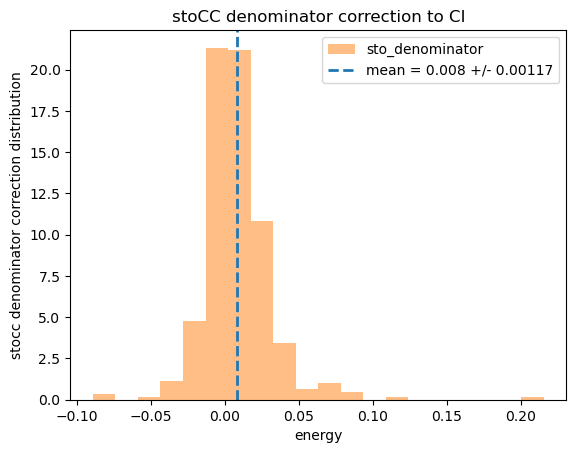

In [57]:
plt.figure()
plt.hist(dencr_sp.real, bins=20, alpha=0.5, density=True, color='C1', label='sto_denominator')
mean = np.mean(dencr_sp.real)
sigma = np.std(dencr_sp.real)/np.sqrt(len(dencr_sp))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc denominator correction distribution")
plt.title("stoCC denominator correction to CI")
plt.legend()
plt.show()

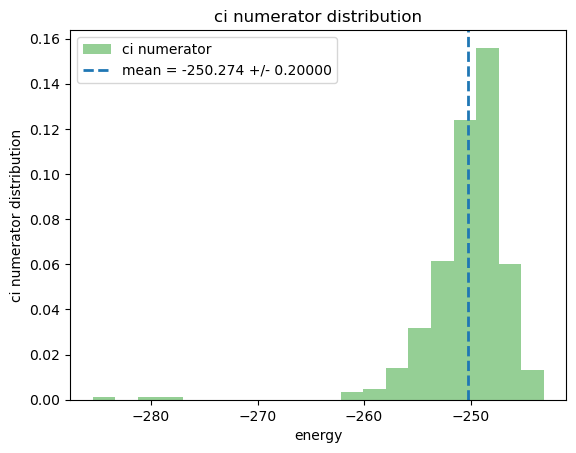

In [22]:
plt.figure()
plt.hist(numci_sp.real, bins=20, alpha=0.5, density=True, color='C2', label='ci numerator')
mean = np.mean((numci_sp).real)
sigma = np.std((numci_sp).real)/np.sqrt(len((numci_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("ci numerator distribution")
plt.title("ci numerator distribution")
plt.legend()
plt.show()

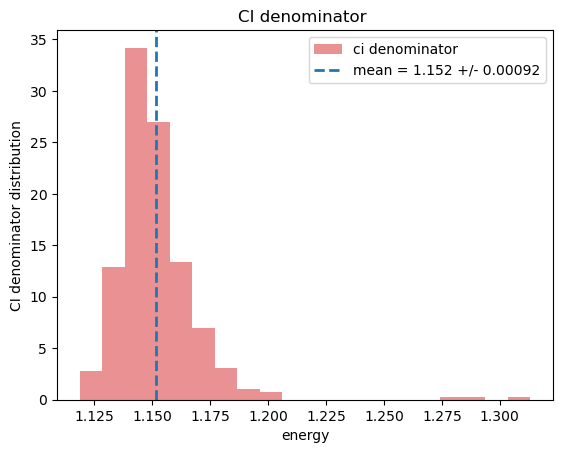

In [23]:
plt.figure()
plt.hist((denci_sp).real, bins=20, alpha=0.5, density=True, color='C3', label='ci denominator')
mean = np.mean((denci_sp).real)
sigma = np.std((denci_sp).real)/np.sqrt(len((denci_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("CI denominator distribution")
plt.title("CI denominator ")
plt.legend()
plt.show()

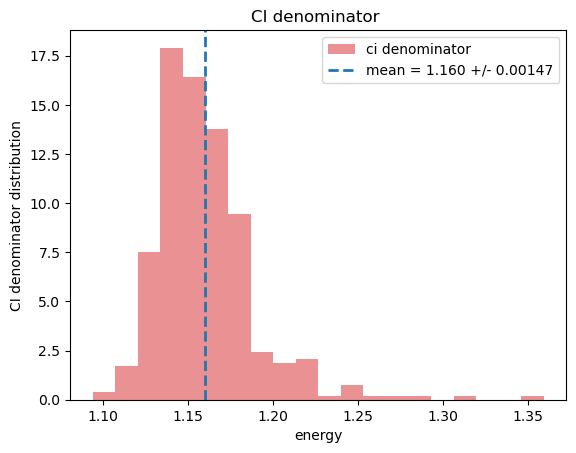

In [58]:
plt.figure()
plt.hist((denci_sp+dencr_sp).real, bins=20, alpha=0.5, density=True, color='C3', label='ci denominator')
mean = np.mean((denci_sp+dencr_sp).real)
sigma = np.std((denci_sp+dencr_sp).real)/np.sqrt(len((denci_sp+dencr_sp)))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
plt.xlabel("energy")
plt.ylabel("CI denominator distribution")
plt.title("CI denominator ")
plt.legend()
plt.show()

In [17]:
covci

array([[ 0.00055659+0.00000000e+00j, -0.00024954+2.34942037e-07j],
       [-0.00024954-2.34942037e-07j,  0.00011219+0.00000000e+00j]])

In [18]:
print(covcc.real)

[[ 5.56587443e-04  1.41484308e-05 -2.49538903e-04 -1.20757264e-05]
 [ 1.41484308e-05  2.18286674e-06 -6.19485679e-06 -2.79509046e-06]
 [-2.49538903e-04 -6.19485679e-06  1.12194461e-04  4.73804600e-06]
 [-1.20757264e-05 -2.79509046e-06  4.73804600e-06  5.84557229e-06]]


In [60]:
decc = [1/(denci+dencr), 
        -(numci+numcr)/(denci+dencr)**2,
        # 1/(denci+dencr),  
        # -(numci+numcr)/(denci+dencr)**2,
        ]
covcc = np.cov([numci_sp+numcr_sp, denci_sp+dencr_sp])
ecc_err = np.sqrt(decc @ covcc @ decc) / np.sqrt((n))
print(ecc_err)

(0.0027438756667803534-1.3568360854872898e-06j)


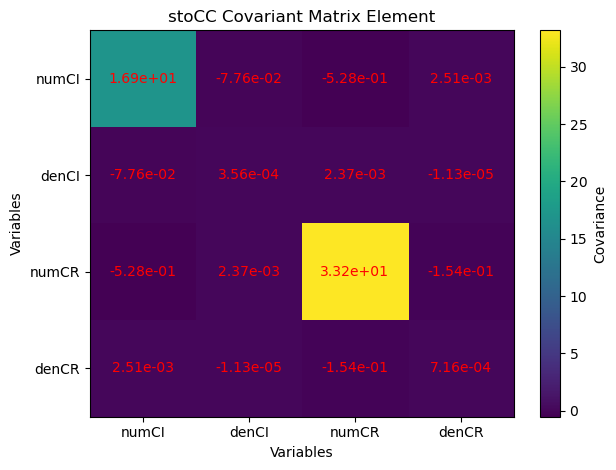

In [25]:
# 5 slater

var_names = ['numCI', 'denCI',
             'numCR', 'denCR']

plt.figure()
im = plt.imshow(covcc.real, origin='upper', aspect='auto')

plt.colorbar(im, label='Covariance')

# Set tick positions
plt.xticks(np.arange(len(var_names)), var_names) #, rotation=45)
plt.yticks(np.arange(len(var_names)), var_names)

plt.xlabel('Variables')
plt.ylabel('Variables')
plt.title('stoCC Covariant Matrix Element')

plt.tight_layout()
# plt.show()

for i in range(covcc.shape[0]):
    for j in range(covcc.shape[1]):
        value = covcc.real[i, j]
        plt.text(j, i, f"{value:.2e}",
                 ha='center', va='center',
                 color='red')
plt.show()

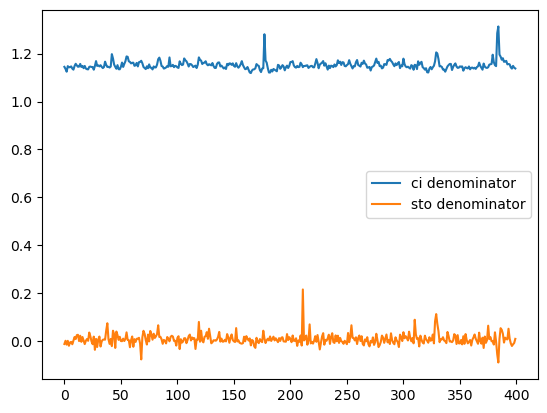

In [27]:
# plt.plot(numci_sp.real,label='ci numerator')
plt.plot(denci_sp.real,label='ci denominator')
# plt.plot(numcr_sp.real,label='sto numerator')
plt.plot(dencr_sp.real,label='sto denominator')
plt.legend()
plt.show()

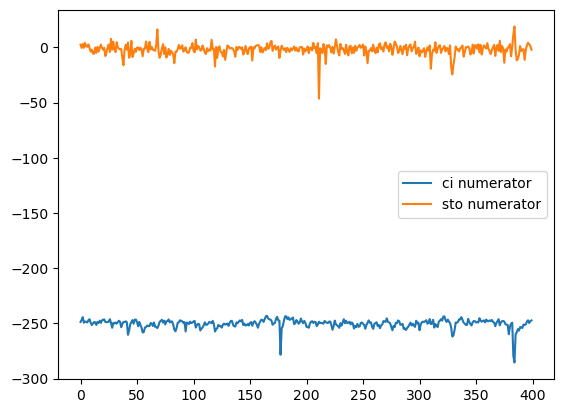

In [28]:
plt.plot(numci_sp.real,label='ci numerator')
plt.plot(numcr_sp.real,label='sto numerator')
plt.legend()
plt.show()

In [ ]:
whf_jk = whf - whf_sp
numci_jk = (whf_numci - whf_sp * numci_sp)
denci_jk = (whf_denci - whf_sp * denci_sp)
numcr_jk = (whf_numcr - whf_sp * numcr_sp)
dencr_jk = (whf_dencr - whf_sp * dencr_sp)

nsample_jk = len(whf_jk)
ecc_jk = (numci_jk + numcr_jk) / (denci_jk + dencr_jk)
ecc_jk_mean = np.sum(ecc_jk) / (nsample_jk)
ecc_jk_err = np.sqrt(np.sum((ecc_jk-ecc_jk_mean)**2) * (nsample_jk-1)/nsample_jk)
print(f'Jackknife CCSD Energy: {ecc_jk_mean.real:.6f} +/- {ecc_jk_err.real:.6f}')

Jackknife CCSD Energy: -217.346815 +/- 0.001974


In [ ]:
import numpy as np

def block_jackknife(weights, n_ci, n_cr, d_ci, d_cr, block_size):
    """
    Performs Block Jackknife on the ratio estimator E = (<N_ci> + <N_cr>) / (<D_ci> + <D_cr>)
    """
    # 1. Ensure all inputs are numpy arrays
    w = np.array(weights)
    n1, n2 = np.array(n_ci), np.array(n_cr)
    d1, d2 = np.array(d_ci), np.array(d_cr)
    
    # 2. Calculate weighted components per sample
    # (Total Numerator and Total Denominator contributions per sample)
    num_samples = (len(w) // block_size) * block_size
    # print(num_samples)
    weighted_num = (w * (n1 + n2))[:num_samples]
    weighted_den = (w * (d1 + d2))[:num_samples]
    
    # 3. Reshape and sum into Blocks
    num_blocks = num_samples // block_size
    # We sum the weighted values within each block
    block_sums_num = weighted_num.reshape(num_blocks, block_size).sum(axis=1)
    block_sums_den = weighted_den.reshape(num_blocks, block_size).sum(axis=1)
    
    # 4. Calculate Global Totals
    total_num = np.sum(block_sums_num)
    total_den = np.sum(block_sums_den)
    
    # 5. Generate Jackknife Estimates (Leave-One-Block-Out)
    # e_jk[j] is the energy calculated excluding block j
    e_jk = (total_num - block_sums_num) / (total_den - block_sums_den)
    
    # 6. Calculate Jackknife Statistics
    m = num_blocks
    mean_jk = np.mean(e_jk)
    # The (m-1) factor is the standard Jackknife variance scaling
    err_jk = np.sqrt((m - 1) / m * np.sum((e_jk - mean_jk)**2))
    
    return err_jk.real

In [72]:
nblk = 20
# blks = [1,2,3,4,5,6,7,8,9,10]
def blocking(whf_sp, numci_sp, numcr_sp, denci_sp, dencr_sp, nblk=None):
    if nblk is None:
        nblk = len(whf_sp) // 10
    e = np.zeros(nblk)
    err = np.zeros(nblk)
    thresh = 1.05
    print(f'b_size Energy_JK Error_JK')
    for i in range(nblk):
        e[i], err[i] = block_jackknife(whf_sp, numci_sp, numcr_sp, denci_sp, dencr_sp, block_size=i+1)
        print(f'{i+1} {e[i]:.6f} {err[i]:.6f}')
        if err[i] < err[i-1]*thresh:
            break
    return err[i]

In [73]:
err = blocking(whf_sp, numci_sp, numcr_sp, denci_sp, dencr_sp, nblk=None)
print(err)

b_size Energy_JK Error_JK
1 -217.346815 0.001974
2 -217.346815 0.002067
0.0020674966466289776


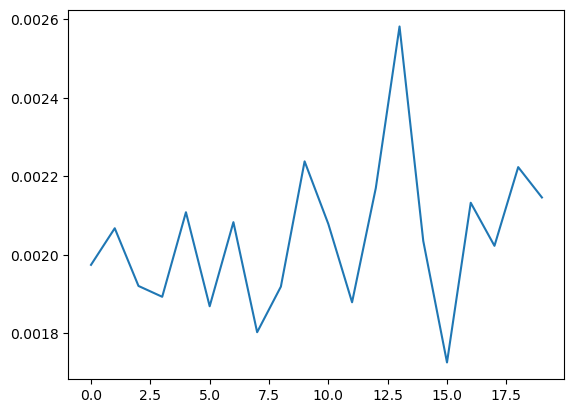

In [52]:
plt.plot(err)

In [ ]:

def find_outliers_mad(x, threshold=20.0):
    x = np.asarray(x)

    median = np.median(x)
    mad = np.median(np.abs(x - median))

    # Avoid division-by-zero if all values identical
    if mad == 0:
        return x, np.array([], dtype=int)

    modified_z = 0.6745 * (x - median) / mad
    mask_clean = np.abs(modified_z) <= threshold

    # cleaned = x[mask]
    removed_idx = np.where(~mask_clean)[0]

    return mask_clean, removed_idx

def reomve_outliers(data, mask_clean):
    return [x[mask_clean] for x in data]

In [88]:
mask_clean, outlier_idx = find_outliers_mad(ecc_jk.real, threshold=20.0)
print(outlier_idx)
print(mask_clean.sum())

[673 852]
998


In [90]:
data = [whf_sp, numci_sp, denci_sp, numcr_sp, dencr_sp]
[whf_clean, numci_clean, denci_clean, numcr_clean, dencr_clean] = reomve_outliers(data, mask_clean)

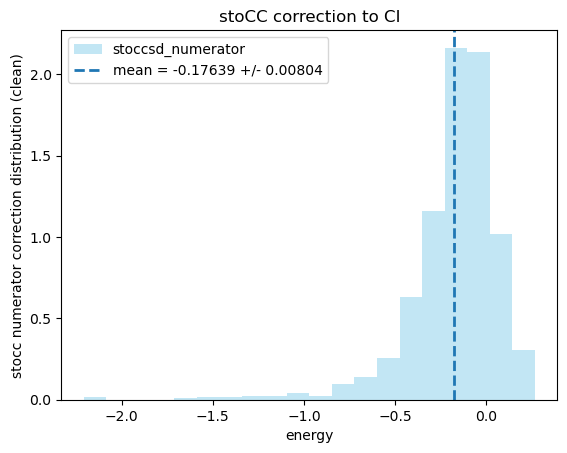

In [95]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(numcr_clean.real, bins=20, alpha=0.5, density=True, color='skyblue', label='stoccsd_numerator')
mean = np.mean(numcr_clean.real)
sigma = np.std(numcr_clean.real)/np.sqrt(len(numcr_clean))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
# plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("stocc numerator correction distribution (clean)")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

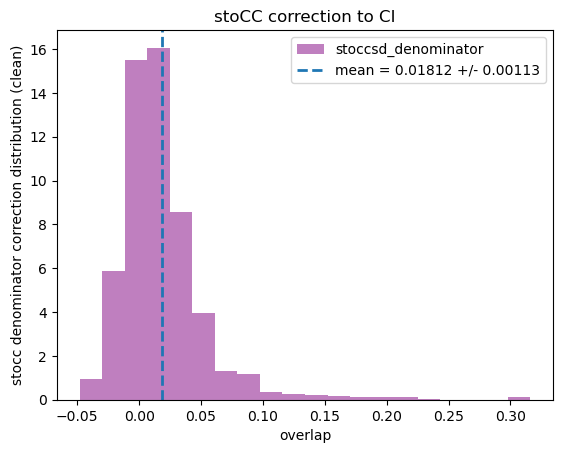

In [94]:
plt.figure()
plt.hist(dencr_clean.real, bins=20, alpha=0.5, density=True, color='purple', label='stoccsd_denominator')
mean = np.mean(dencr_clean.real)
sigma = np.std(dencr_clean.real)/np.sqrt(len(dencr_clean))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.xlabel("overlap")
plt.ylabel("stocc denominator correction distribution (clean)")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

In [96]:
whf = np.sum(whf_clean)
whf_numci = np.sum(whf_clean * numci_clean)
whf_denci = np.sum(whf_clean * denci_clean)
whf_numcr = np.sum(whf_clean * numcr_clean)
whf_dencr = np.sum(whf_clean * dencr_clean)

In [99]:
(whf_numci + whf_numcr) / (whf_denci + whf_dencr)

np.complex128(-8.76952657069782+0.00014324040333053414j)

In [100]:
whf_jk = whf - whf_clean
numci_jk = (whf_numci - whf_clean * numci_clean) / whf_jk
denci_jk = (whf_denci - whf_clean * denci_clean) / whf_jk
numcr_jk = (whf_numcr - whf_clean * numcr_clean) / whf_jk
dencr_jk = (whf_dencr - whf_clean * dencr_clean) / whf_jk

#CCSD
ecc_jk = (numci_jk + numcr_jk) / (denci_jk + dencr_jk)
# for i in range(len(whf_jk)):
#     print(f'  {i+1}  {ecc_jk.real[i]:.6f}')
ecc_jk_mean = ecc_jk.mean()
ecc_jk_err = np.std(ecc_jk) * np.sqrt(len(ecc_jk))
print(f'{ecc_jk_mean.real:.6f} +/- {ecc_jk_err.real:.6f}')

-8.769527 +/- 0.001809


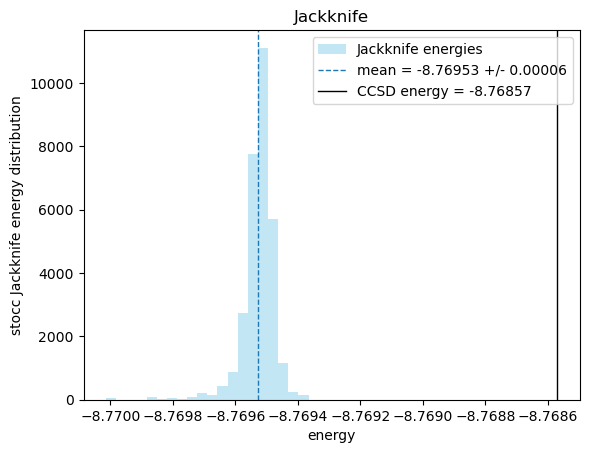

In [101]:
plt.figure()
plt.hist(ecc_jk.real, bins=20, alpha=0.5, density=True, color='skyblue', label='Jackknife energies')
mean = np.mean(ecc_jk.real)
sigma = np.std(ecc_jk.real)
plt.axvline(mean, linestyle="--", linewidth=1, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.axvline(mycc.e_tot, linestyle="-", linewidth=1, color='black', label=f"CCSD energy = {mycc.e_tot:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc Jackknife energy distribution")
plt.title("Jackknife")
plt.legend()
plt.show()